Step 1: Install and Import Required Libraries
Make sure you have the necessary libraries available in your environment (you should already have boto3 pre-installed in SageMaker):

In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import boto3
import pandas as pd
import os
import numpy as np
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from scipy.stats import skew
from scipy.stats.stats import pearsonr
from math import sqrt
from sklearn.metrics import mean_squared_error
#import fbprophet

/tmp/ipykernel_1139/1439754339.py:10: DeprecationWarning: Please import `pearsonr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import pearsonr


Step 2: Set up S3 Client
You need to create a client using boto3 to interact with S3 and access your data.

In [3]:
# Initialize the S3 client
s3_client = boto3.client('s3')

Step 3: Define Your S3 Bucket and File Path
Specify the S3 bucket name and the file path to the dataset inside the bucket.

For example, if your bucket name is my-rossmann-bucket and the dataset file is stored in data/rossmann_sales.csv, set the path accordingly.

In [4]:
import boto3

s3 = boto3.client('s3')
bucket_name = 'keithsbucketaws'
base_key = 'rossmann-data/'  # Adjust if files are in different paths

Step 4: Download the File from S3 to Local Environment (SageMaker Notebook)
To download the file to your SageMaker environment, you can use the following code:

In [5]:
files = ['train.csv', 'test.csv', 'store.csv']
local_dir = '/tmp'

for file in files:
    s3_key = f"{base_key}{file}"  # e.g., "rossmann-data/train.csv"
    local_path = f"{local_dir}/{file}"
    
    s3.download_file(bucket_name, s3_key, local_path)
    print(f"Downloaded {file} to {local_path}")

Downloaded train.csv to /tmp/train.csv
Downloaded test.csv to /tmp/test.csv
Downloaded store.csv to /tmp/store.csv


Step 5: Load the Data into a Pandas DataFrame
Once the file is downloaded, you can read it into a Pandas DataFrame for analysis or preprocessing:

In [6]:
# Load the data into a pandas DataFrame
train = pd.read_csv('/tmp/train.csv', parse_dates = True, low_memory = False, index_col = 'Date')
store = pd.read_csv('/tmp/store.csv')
test = pd.read_csv('/tmp/test.csv', parse_dates = True, low_memory = False, index_col = 'Date')

# EXPLORATORY DATA ANALYSIS - TRAIN
We begin by examining the structure of our data to identify which variables are continuous and which are categorical. During this exploration, we recognize an opportunity to create a new feature: average sales per customer, calculated by dividing the number of sales by the number of customers.

Additionally, we handle missing values in this new feature by assuming that entries with missing data had zero customers—since sales depend on customers, we remove these records entirely.

One important observation is the ordering of the data: it is sorted from the most recent date to the oldest. This reverse chronological order may introduce challenges when building our model.

In [7]:
# Display the first few rows
train.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1
2015-07-31,2,5,6064,625,1,1,0,1
2015-07-31,3,5,8314,821,1,1,0,1
2015-07-31,4,5,13995,1498,1,1,0,1
2015-07-31,5,5,4822,559,1,1,0,1


In [8]:
# Find the shape
train.shape

(1017209, 8)

After that we will use the amazing .describe() function which can provide us most of the statistic elements.

In [9]:
train.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


Check all the missing elements

In [10]:
missing = train.isnull().sum()
missing.sort_values(ascending=False)

Store            0
DayOfWeek        0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

Create a new metric to observe average sales per customer.

In [11]:
train['SalesPerCustomer'] = train['Sales']/train['Customers']
train['SalesPerCustomer'].head()

Date
2015-07-31     9.482883
2015-07-31     9.702400
2015-07-31    10.126675
2015-07-31     9.342457
2015-07-31     8.626118
Name: SalesPerCustomer, dtype: float64

Check if there are any missing values with our new metric and drop them. Either the customers or the sales should be zero to give us a null SalesPerCustomer.

In [12]:
missing = train.isnull().sum()
missing.sort_values(ascending=False)

SalesPerCustomer    172869
Store                    0
DayOfWeek                0
Customers                0
Sales                    0
Open                     0
Promo                    0
StateHoliday             0
SchoolHoliday            0
dtype: int64

In [13]:
train.dropna().head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,SalesPerCustomer
Date,,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1,9.482883
2015-07-31,2,5,6064,625,1,1,0,1,9.702400
2015-07-31,3,5,8314,821,1,1,0,1,10.126675
2015-07-31,4,5,13995,1498,1,1,0,1,9.342457
2015-07-31,5,5,4822,559,1,1,0,1,8.626118


# EXPLORATORY DATA ANALYSIS - STORE
We apply the same preprocessing steps as we did for the training set. Upon examining the data, we find only three missing values in CompetitionDistance. Since this number is negligible, we replace them with the column’s mean.

The remaining missing values are all tied to Promo2—specifically, they occur when Promo2 is inactive (equal to 0). Given this dependency, we fill these nulls with 0 to maintain consistency.

In [14]:
store = pd.read_csv('/tmp/store.csv')

store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [15]:
store.shape

(1115, 10)

In [16]:
store.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

The rows that do not have any Promo2 we can fill the rest of the values with 0

In [17]:
store.fillna(0, inplace = True)

In [18]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,0.0,0.0,0
4,5,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0


Join the data together using an inner join so only the data that is in both data set is joined

In [19]:
train_merged = train.merge(right=store, on='Store', how='left')

# EXPLORATORY DATA ANALYSIS FOR TEST SET

In [20]:
test.head()

,Id,Store,DayOfWeek,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,
2015-09-17,1,1,4,1.0,1,0,0
2015-09-17,2,3,4,1.0,1,0,0
2015-09-17,3,7,4,1.0,1,0,0
2015-09-17,4,8,4,1.0,1,0,0
2015-09-17,5,9,4,1.0,1,0,0


In [21]:
test.shape

(41088, 7)

In [22]:
test.describe()

,Id,Store,DayOfWeek,Open,Promo,SchoolHoliday
count,41088.000000,41088.000000,41088.000000,41077.000000,41088.000000,41088.000000
mean,20544.500000,555.899533,3.979167,0.854322,0.395833,0.443487
std,11861.228267,320.274496,2.015481,0.352787,0.489035,0.496802
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,10272.750000,279.750000,2.000000,1.000000,0.000000,0.000000
50%,20544.500000,553.500000,4.000000,1.000000,0.000000,0.000000
75%,30816.250000,832.250000,6.000000,1.000000,1.000000,1.000000
max,41088.000000,1115.000000,7.000000,1.000000,1.000000,1.000000


Check missing elements

In [23]:
missing = test.isnull().sum()
missing.sort_values(ascending=False)

Open             11
Store             0
Id                0
DayOfWeek         0
Promo             0
StateHoliday      0
SchoolHoliday     0
dtype: int64

In this visualization, we plot the distribution of sales across our dataset. Due to the high volume of transactions, the graph appears as a solid blue mass, making individual data points difficult to distinguish. Nevertheless, the plot still provides valuable insight into the overall distribution of sales.

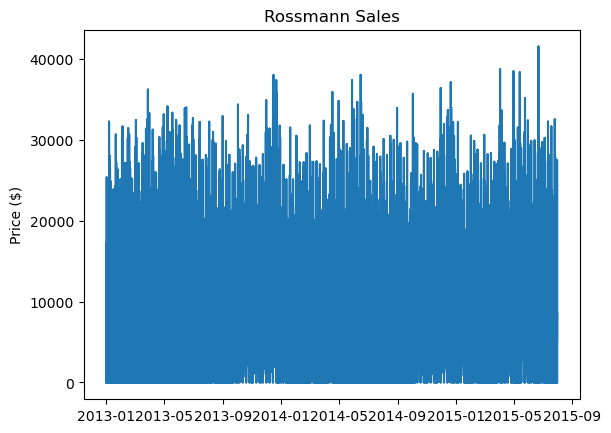

In [24]:
plt.plot(train.index, train['Sales'])
plt.title('Rossmann Sales')
plt.ylabel('Price ($)');
plt.show()

To clean up our graph, we want to form a new column which only accounts for the year of the sales.

In [25]:
train['Year'] = train.index.year

# Take Dates from index and move to Date column 
train.reset_index(level=0, inplace = True)
#train['sales'] = 0

In [26]:
test['Year'] = test.index.year

# Take Dates from index and move to Date column 
test.reset_index(level=0, inplace = True)
#test['sales'] = 0

In [27]:
train_store = train
test_store = test

In [28]:
# Convert Date columns and set as index
train_store['Date'] = pd.to_datetime(train_store['Date'], format="%Y-%m-%d")
train_store = train_store.set_index('Date')

test_store['Date'] = pd.to_datetime(test_store['Date'], format="%Y-%m-%d")
test_store = test_store.set_index('Date')

# Resample with explicit numeric_only=True to avoid warnings
train_store = train_store.resample('D').mean(numeric_only=True)
train_store = train_store.interpolate(method='linear')

test_store = test_store.resample('D').mean(numeric_only=True)
test_store = test_store.interpolate(method='linear')

<Axes: title={'center': 'daily sales'}, xlabel='Date'>

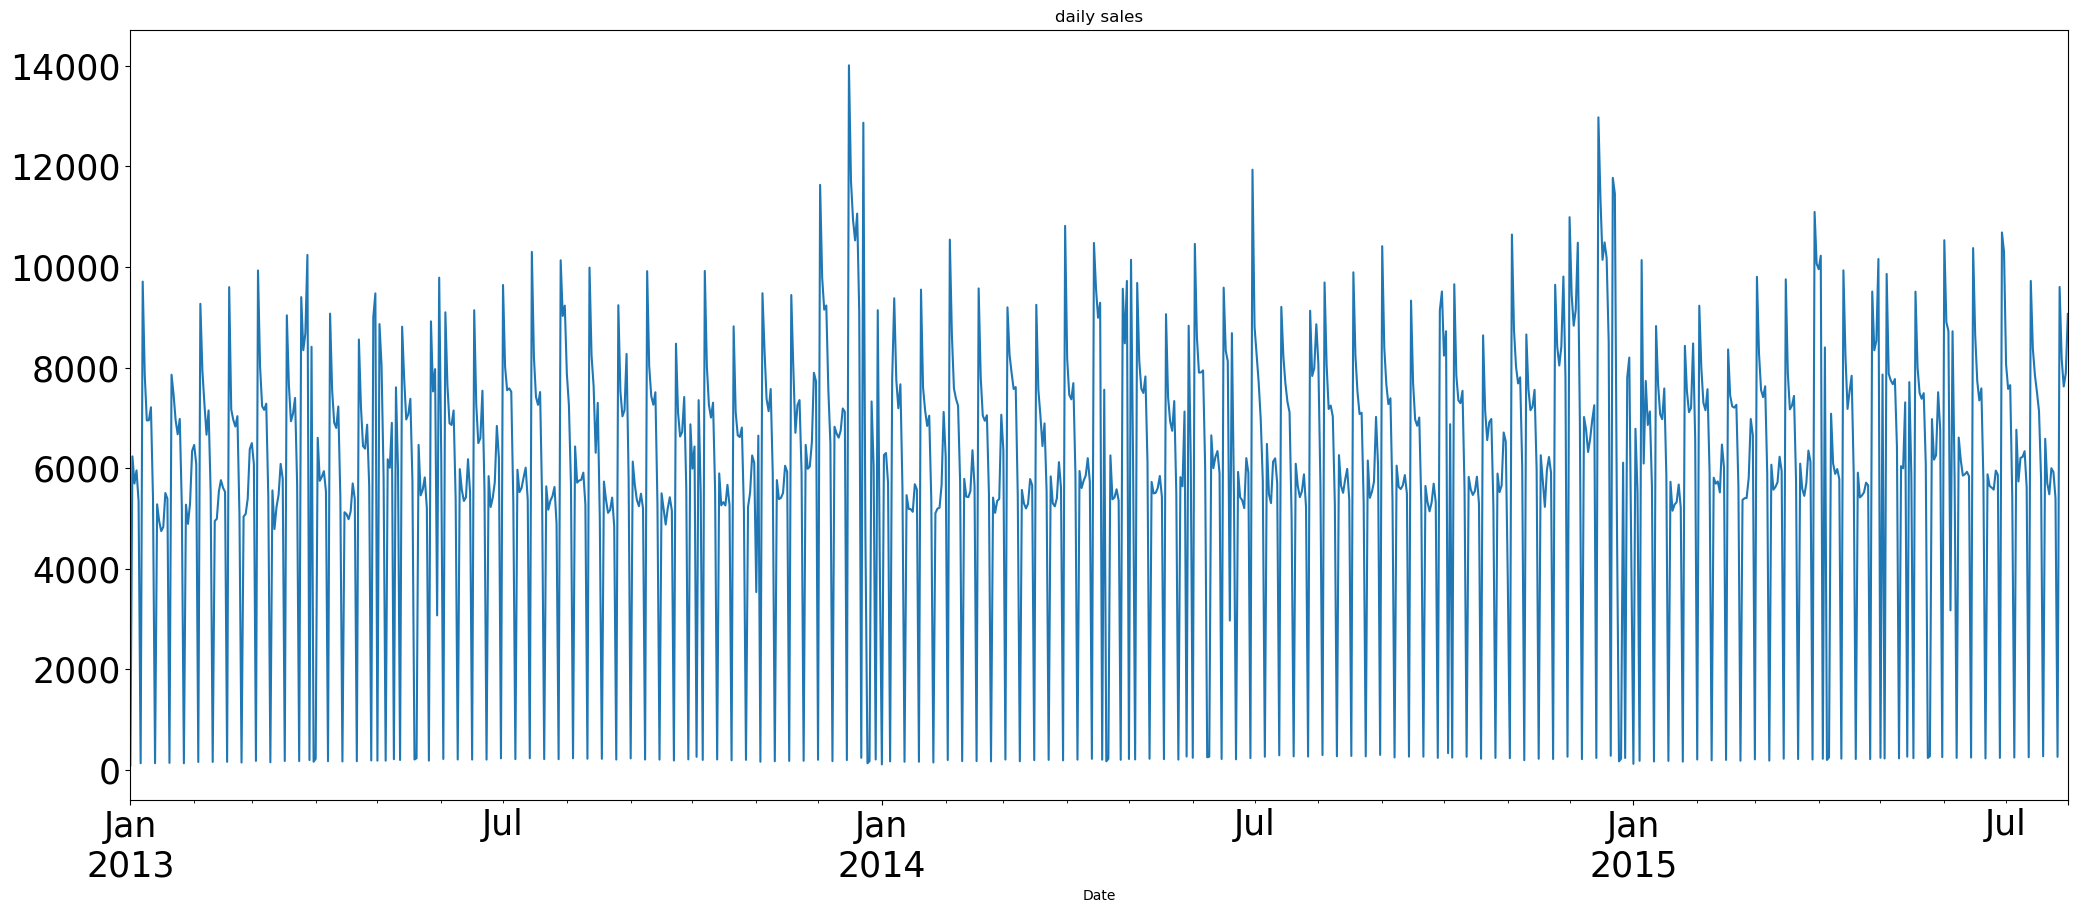

In [29]:
train_store.Sales.plot(figsize=(25,10), title='daily sales', fontsize=25)
#test_store.Sales.plot()

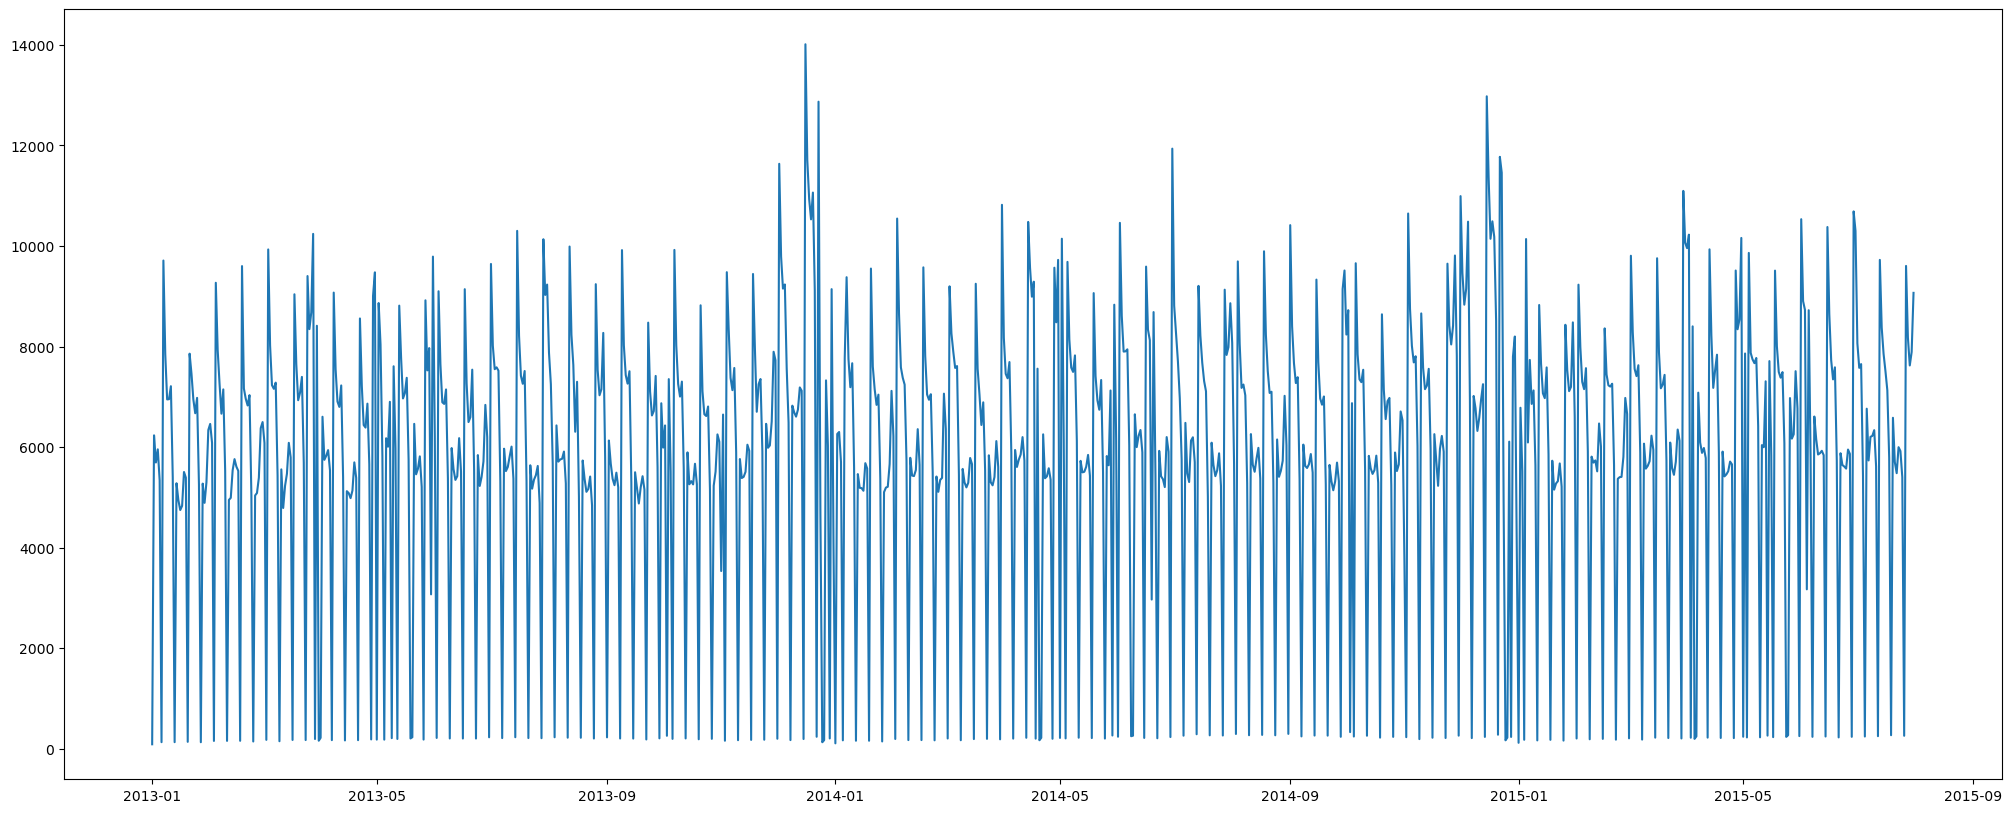

In [30]:
y_hat_avg_moving = test_store.copy()
y_hat_avg_moving['moving_avg_forcast'] = train_store.Sales.rolling(90).mean().iloc[-1]
plt.figure(figsize=(25,10))
plt.plot(train_store['Sales'], label='Train')
#plt.plot(test_store['Sales'], label='Test')
#plt.plot(y_hat_avg_moving['moving_avg_forcast'], label='Moving Forecast')
#plt.legend(loc='best')
#plt.title('Moving Average Forecast')

In [31]:
rms_avg_rolling = sqrt(mean_squared_error(test_store.Sales, y_hat_avg_moving.moving_avg_forcast))
print('ROLLING AVERAGE',rms_avg_rolling)

AttributeError: 'DataFrame' object has no attribute 'Sales'

In [32]:
train_store.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,SalesPerCustomer,Year
Date,,,,,,,,,
2013-01-01,557.614004,2.0,87.284560,17.496409,0.015260,0.0,1.000000,4.989809,2013.0
2013-01-02,558.000000,3.0,6233.030493,748.049327,0.996413,0.0,1.000000,8.738103,2013.0
2013-01-03,558.000000,4.0,5693.112108,682.547085,0.994619,0.0,0.932735,8.755473,2013.0
2013-01-04,558.000000,5.0,5954.218834,701.468161,0.993722,0.0,0.932735,8.861041,2013.0
2013-01-05,558.000000,6.0,5337.751570,616.566816,0.992825,0.0,0.100448,9.007924,2013.0


In [33]:
test_store.head()

,Id,Store,DayOfWeek,Open,Promo,SchoolHoliday,Year
Date,,,,,,,
2015-08-01,40660.5,555.899533,6.0,1.000000,0.0,0.156542,2015.0
2015-08-02,39804.5,555.899533,7.0,0.031542,0.0,0.156542,2015.0
2015-08-03,38948.5,555.899533,1.0,1.000000,1.0,1.000000,2015.0
2015-08-04,38092.5,555.899533,2.0,1.000000,1.0,1.000000,2015.0
2015-08-05,37236.5,555.899533,3.0,1.000000,1.0,1.000000,2015.0


We can create a simple mapping from train_store

In [34]:
# Average SalesPerCustomer by Store
store_avg_spc = train_store.groupby('Store')['SalesPerCustomer'].mean()

# Round stores first to int
train_store['Store'] = train_store['Store'].astype(int)
test_store['Store'] = test_store['Store'].astype(int)

# Map into test set
test_store['SalesPerCustomer'] = test_store['Store'].map(store_avg_spc)

# Fill NA if some stores weren’t in training
test_store['SalesPerCustomer'].fillna(store_avg_spc.mean(), inplace=True)


/tmp/ipykernel_1139/1081348866.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_store['SalesPerCustomer'].fillna(store_avg_spc.mean(), inplace=True)


In [35]:
# 1. Convert types
test_store['Id'] = test_store['Id'].astype(int)
test_store['Store'] = test_store['Store'].astype(int)
train_store['Store'] = train_store['Store'].astype(int)

# 2. Binarize Open
train_store['Open'] = (train_store['Open'] > 0.5).astype(int)
test_store['Open'] = (test_store['Open'] > 0.5).astype(int)

# 3. Feature/target prep
features = [
    'Store', 'DayOfWeek', 'Open', 'Promo', 
    'SchoolHoliday', 'SalesPerCustomer', 'Year'
]
X_train = train_store[features]
y_train = train_store['Sales']
X_test = test_store[features]


In [36]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)
preds = model.predict(X_test)

# Clip negative sales, if any
preds = preds.clip(0)

test_store['PredictedSales'] = preds

# Save to CSV
submission = test_store[['Id', 'PredictedSales']]
submission.to_csv("rossmann_submission.csv", index=False)

print("✅ Sales prediction complete. File saved as `rossmann_submission.csv`!")


✅ Sales prediction complete. File saved as `rossmann_submission.csv`!


🎯 1. Validate with Metrics (RMSE, R²)
Since you're predicting on test data (without ground truth), we’ll slice off a chunk off the training data as a validation set to eval the model.

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Split train into sub-train and validation
X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# Train on sub-train
model.fit(X_subtrain, y_subtrain)

# Predict on validation
y_val_pred = model.predict(X_val)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)

print(f"🧮 RMSE: {rmse:.2f}")
print(f"📈 R² Score: {r2:.4f}")


🧮 RMSE: 449.26
📈 R² Score: 0.9700


🔍 2. Feature Importance

/tmp/ipykernel_1139/3608451380.py:13: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


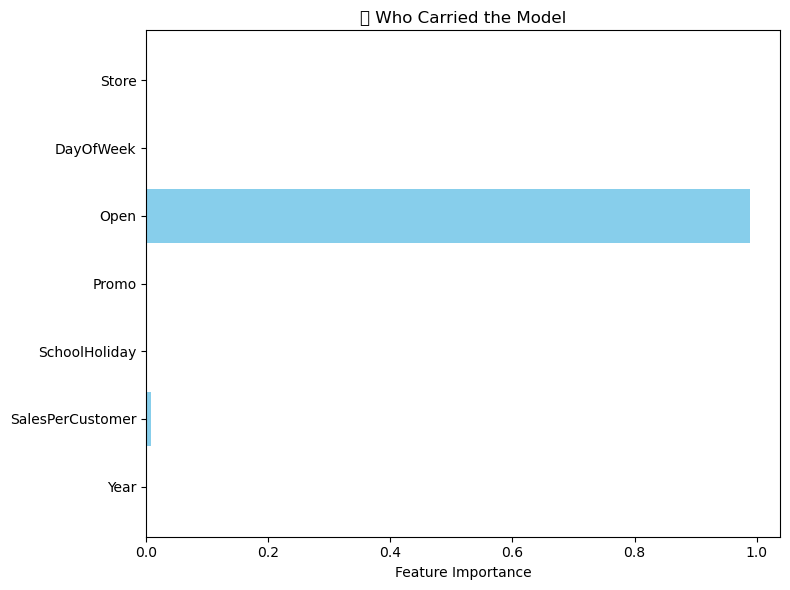

In [38]:
import matplotlib.pyplot as plt

# Get feature importance
importances = model.feature_importances_
feat_names = X_train.columns

# Plot
plt.figure(figsize=(8, 6))
plt.barh(feat_names, importances, color='skyblue')
plt.xlabel("Feature Importance")
plt.title("🔥 Who Carried the Model")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

📊 3. Visualize Predictions vs. Actuals

/tmp/ipykernel_9877/1048180573.py:9: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


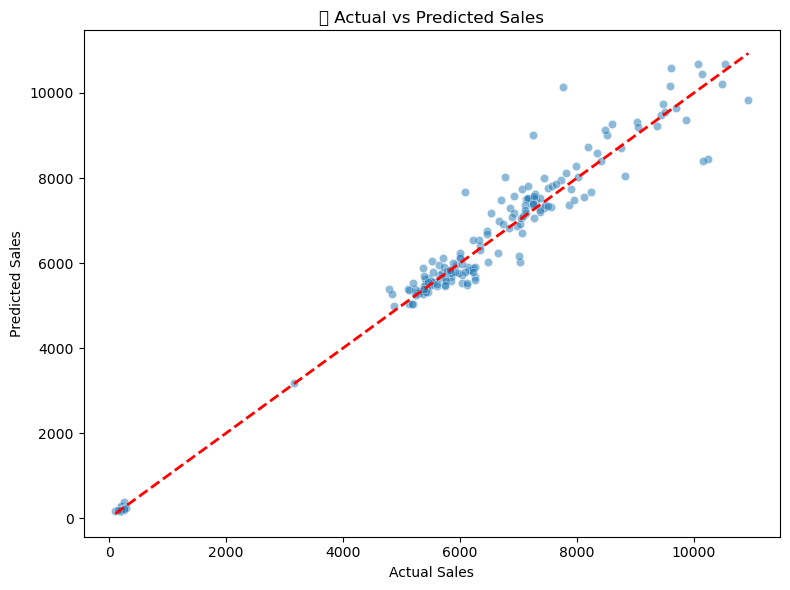

In [123]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_val, y=y_val_pred, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', linewidth=2)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("🎯 Actual vs Predicted Sales")
plt.tight_layout()
plt.show()
